# Ch15 伺服馬達與驅動器(Basics of the Electric Servomotor and Drive)

**對應原書**:Chapter 15
**軟體替代**:ModelQ 馬達/驅動器方塊 → `DCMotorPlant`(含電氣動態)+ 串級電流/速度迴路

## 學習目標
1. 設計**電流迴路**:PI 零點對消電氣極點($k_p = L\omega_c$、$k_i = R\omega_c$)。
2. 理解串級頻寬分離法則:電流迴路頻寬 ≈ 速度迴路的 10 倍。
3. 看見電壓飽和與電流極限如何限制動態(轉矩受限的加速)。

## 馬達參數
R=1 Ω, L=1 mH, Kt=Ke=0.1, J=1e-4 kg·m², b=1e-5(電氣極點 1000 rad/s ≈ 159 Hz)

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

電流迴路 PI:kp=5.027, ki=5027(零點 = ki/kp = 1000 rad/s = 電氣極點 R/L)


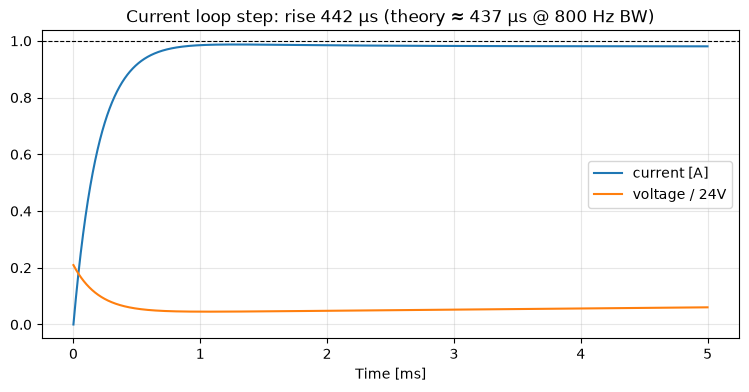

10–90% 上升時間 442 µs,理論 0.35/BW = 437 µs


In [2]:
R, L_ind, Kt, Ke = 1.0, 1e-3, 0.1, 0.1
J, b = 1e-4, 1e-5
dt = 1e-6                      # 模擬步長 1 µs(電流迴路很快)

# --- 電流迴路:極點對消設計,目標頻寬 800 Hz ---
wc_i = 2 * np.pi * 800
kp_i, ki_i = L_ind * wc_i, R * wc_i
print(f'電流迴路 PI:kp={kp_i:.3f}, ki={ki_i:.0f}(零點 = ki/kp = {ki_i/kp_i:.0f} rad/s = 電氣極點 R/L)')

n = int(0.005 / dt)
motor = DCMotorPlant(R=R, L=L_ind, Kt=Kt, Ke=Ke, J=J, b=b, dt=dt)
ci = DiscretePID(kp_i, ki_i, dt=dt, out_min=-24, out_max=24)
i_log, v_log = np.empty(n), np.empty(n)
for k in range(n):
    i_log[k] = motor.i
    v = ci.step(1.0 - motor.i)          # 1 A 電流步階命令
    v_log[k] = v
    motor.step(v)
t_i = np.arange(n) * dt

t10 = t_i[np.nonzero(i_log >= 0.1)[0][0]]
t90 = t_i[np.nonzero(i_log >= 0.9)[0][0]]
rise_us = (t90 - t10) * 1e6
theory_us = 0.35 / 800 * 1e6
plt.figure(figsize=(9, 4))
plt.plot(t_i * 1000, i_log, label='current [A]')
plt.plot(t_i * 1000, v_log / 24, label='voltage / 24V')
plt.axhline(1, color='k', ls='--', lw=0.8)
plt.xlabel('Time [ms]'); plt.legend(); plt.grid(alpha=0.3)
plt.title(f'Current loop step: rise {rise_us:.0f} µs (theory ≈ {theory_us:.0f} µs @ 800 Hz BW)')
plt.show()
print(f'10–90% 上升時間 {rise_us:.0f} µs,理論 0.35/BW = {theory_us:.0f} µs')

## 串級速度迴路

速度迴路(80 Hz 頻寬,電流迴路的 1/10)輸出電流命令,電流極限 ±5 A。
大步階(100 rad/s)期間電流貼著極限 —— **轉矩受限的等加速段**,
這是每台伺服機都看得到的波形。

速度迴路 PI:kp=0.5027, ki=25.266


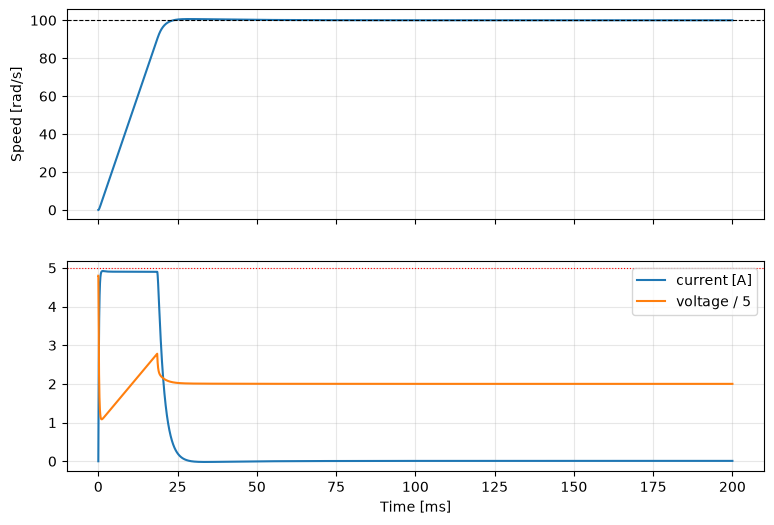

穩態:轉速 100.00 rad/s,電壓 10.01 V(理論 Ke·w + R·i = 10.01 V)
峰值電流 4.92 A(極限 5 A),overshoot 0.65 rad/s


In [3]:
wc_v = 2 * np.pi * 80
kp_v = J * wc_v / Kt
ki_v = kp_v * 2 * np.pi * 8
print(f'速度迴路 PI:kp={kp_v:.4f}, ki={ki_v:.3f}')

n2 = int(0.2 / dt)
motor = DCMotorPlant(R=R, L=L_ind, Kt=Kt, Ke=Ke, J=J, b=b, dt=dt)
ci = DiscretePID(kp_i, ki_i, dt=dt, out_min=-24, out_max=24)
cv = DiscretePID(kp_v, ki_v, dt=dt, out_min=-5, out_max=5)   # 電流極限 ±5 A
w_log, ia_log, va_log = np.empty(n2), np.empty(n2), np.empty(n2)
for k in range(n2):
    w_log[k], ia_log[k] = motor.w, motor.i
    i_cmd = cv.step(100.0 - motor.w)
    va_log[k] = ci.step(i_cmd - motor.i)
    motor.step(va_log[k])
t_v = np.arange(n2) * dt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(t_v * 1000, w_log); ax1.axhline(100, color='k', ls='--', lw=0.8)
ax1.set_ylabel('Speed [rad/s]'); ax1.grid(alpha=0.3)
ax2.plot(t_v * 1000, ia_log, label='current [A]')
ax2.plot(t_v * 1000, va_log / 5, label='voltage / 5')
ax2.axhline(5, color='r', ls=':', lw=0.8)
ax2.set_xlabel('Time [ms]'); ax2.legend(); ax2.grid(alpha=0.3)
plt.show()

v_bemf_expect = Ke * 100 + R * (b * 100 / Kt)
print(f'穩態:轉速 {w_log[-1]:.2f} rad/s,電壓 {va_log[-1]:.2f} V(理論 Ke·w + R·i = {v_bemf_expect:.2f} V)')
print(f'峰值電流 {ia_log.max():.2f} A(極限 5 A),overshoot {w_log.max()-100:.2f} rad/s')

In [4]:
# ✅ 驗證
assert abs(rise_us - theory_us) / theory_us < 0.4         # 電流迴路頻寬達標
assert abs(i_log[-1] - 1.0) < 0.05                        # 電流無穩態誤差
assert ia_log.max() <= 5.0 + 1e-6                         # 電流極限被尊重
assert abs(w_log[-1] - 100) < 0.5                         # 速度到位
assert abs(va_log[-1] - v_bemf_expect) < 0.5              # 穩態電壓 = 反電動勢 + IR
assert (ia_log > 4.5).sum() * dt > 0.01                   # 有明顯的電流受限段
print('Ch15 驗證通過 ✅')

Ch15 驗證通過 ✅


## 練習
1. 把電流迴路頻寬降到 160 Hz(與速度迴路只差 2 倍),速度迴路 step response 出現什麼?
   —— 這就是「頻寬分離不足」的代價。
2. 電壓極限從 24 V 降到 6 V,高速段(反電動勢大)電流還追得上命令嗎?畫出電壓飽和區。
3. 加入負載轉矩 0.05 Nm,速度迴路的恢復波形與第 7 章的預測一致嗎?
4. 把 Kt 誤差 +20%(磁鐵溫升),電流迴路與速度迴路各受多少影響?為什麼電流迴路無感?